In [1]:
import pandas as pd
import numpy as np

# 1. Load Data
# Ensure 'OGORBcsv.csv' is in your directory
df = pd.read_csv('OGORBcsv.csv')
print(f"Initial Data Shape: {df.shape}")

# 2. Date Standardization
df['Production Date'] = pd.to_datetime(df['Production Date'])

# 3. Volume Cleaning
# Remove commas and convert to float
df['Volume'] = df['Volume'].astype(str).str.replace(',', '').astype(float)

# 4. Handling Missing Values
# Fill missing Offshore Regions with 'Onshore' and update State accordingly
df['Offshore Region'] = df['Offshore Region'].fillna('Onshore')
df['State'] = df['State'].fillna(df['Offshore Region'])

# 5. Filter: Natural Gas Only
# Focus on Gas as it is the primary commodity subject to flaring/venting
df_gas = df[df['Commodity'].str.contains('Gas', case=False, na=False)].copy()

# 6. Feature Engineering: Categorize Disposition
def categorize_disposition(desc):
    desc = str(desc).lower()
    if 'sales' in desc:
        return 'Sales'
    elif 'flare' in desc or 'vent' in desc:
        return 'Waste' # Flaring or Venting
    else:
        return 'Other'

df_gas['Category'] = df_gas['Disposition Description'].apply(categorize_disposition)

# 7. Pivot & Aggregation
# Aggregate Volume by Date, State, and Category
df_pivot = df_gas.pivot_table(
    index=['Production Date', 'State'],
    columns='Category',
    values='Volume',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_pivot.columns.name = None 

# 8. Calculate Efficiency Metrics
df_pivot['Total_Production'] = df_pivot['Sales'] + df_pivot['Waste'] + df_pivot['Other']

# Waste Ratio (Percentage of gas lost/flared)
# Added small epsilon (0.0001) to avoid division by zero
df_pivot['Waste_Ratio'] = df_pivot['Waste'] / (df_pivot['Total_Production'] + 0.0001)
df_pivot['Sales_Ratio'] = df_pivot['Sales'] / (df_pivot['Total_Production'] + 0.0001)

# Filter out zero production records
df_final = df_pivot[df_pivot['Total_Production'] > 0].copy()
df_final = df_final.sort_values(['State', 'Production Date'])

# Save processed data
df_final.to_csv('processed_gas_efficiency.csv', index=False)
print("Preprocessing complete. File 'processed_gas_efficiency.csv' saved successfully.")

Initial Data Shape: (470830, 11)
Preprocessing complete. File 'processed_gas_efficiency.csv' saved successfully.


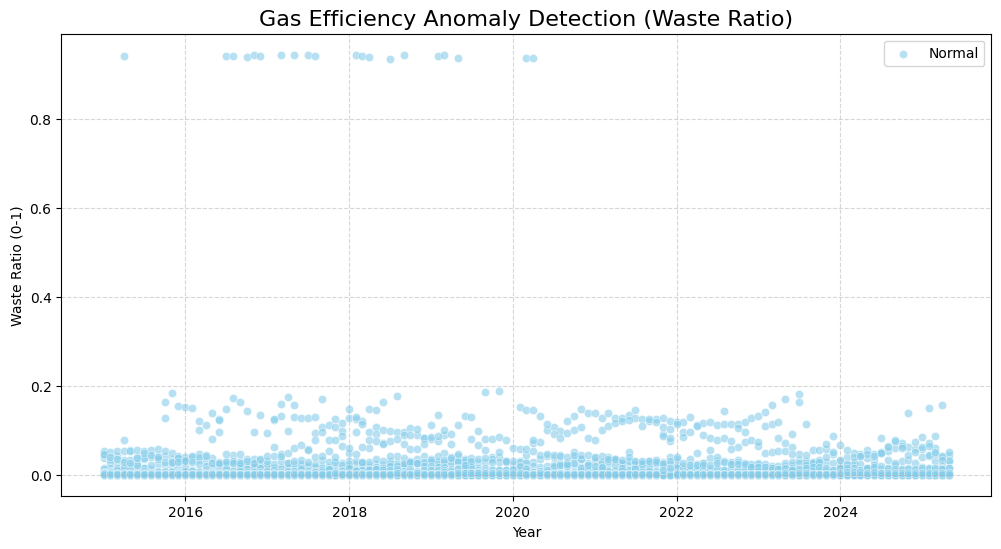

Model Performance (MAE): 0.0031
The model's prediction error is approximately 0.31% on average.


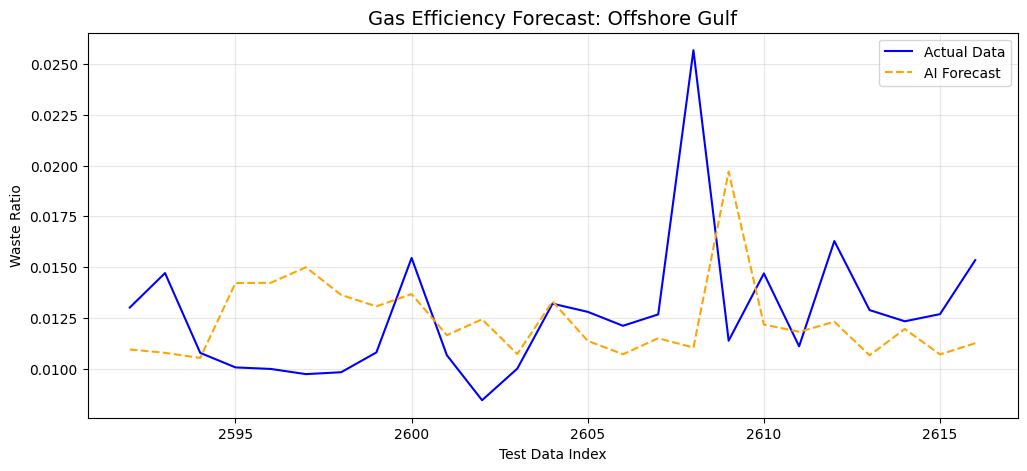

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# --- LOAD DATA ---
df = pd.read_csv('processed_gas_efficiency.csv')
df['Production Date'] = pd.to_datetime(df['Production Date'])

# --- 1. ANOMALY DETECTION (Isolation Forest) ---
# Filter for significant production regions to reduce noise
df_model = df[df['Total_Production'] > 1000].copy()

# Feature: Waste Ratio (Higher ratio = potential inefficiency)
X_anomaly = df_model[['Waste_Ratio']]

# Train Model (Assuming 5% contamination/anomaly rate)
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_anomaly)

# Predict: 1 = Normal, -1 = Anomaly
df_model['Anomaly_Score'] = iso_model.predict(X_anomaly)
df_model['Status'] = df_model['Anomaly_Score'].apply(lambda x: 'Normal' if x == 1 else 'ANOMALY')

# Visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_model[df_model['Status'] == 'Normal'], 
    x='Production Date', y='Waste_Ratio', 
    color='skyblue', label='Normal', alpha=0.6
)
sns.scatterplot(
    data=df_model[df_model['Status'] == 'ANOMALI'], 
    x='Production Date', y='Waste_Ratio', 
    color='red', s=100, label='Anomaly (High Waste)'
)
plt.title('Gas Efficiency Anomaly Detection (Waste Ratio)', fontsize=16)
plt.ylabel('Waste Ratio (0-1)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# --- 2. FORECASTING (Random Forest) ---
# Select a specific region for testing (e.g., Offshore Gulf)
region_name = 'Offshore Gulf'
df_region = df[df['State'] == region_name].sort_values('Production Date').copy()

# Create Lag Features (Using past data to predict future)
df_region['Waste_Ratio_Lag1'] = df_region['Waste_Ratio'].shift(1) # T-1 Month
df_region['Waste_Ratio_Lag3'] = df_region['Waste_Ratio'].shift(3) # T-3 Months
df_region['Total_Prod_Lag1'] = df_region['Total_Production'].shift(1)
df_region = df_region.dropna()

# Split Data
features = ['Waste_Ratio_Lag1', 'Waste_Ratio_Lag3', 'Total_Prod_Lag1']
X = df_region[features]
y = df_region['Waste_Ratio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
predictions = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Performance (MAE): {mae:.4f}")
print(f"The model's prediction error is approximately {mae*100:.2f}% on average.")

# Plot Forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label='Actual Data', color='blue')
plt.plot(y_test.index, predictions, label='AI Forecast', color='orange', linestyle='--')
plt.title(f'Gas Efficiency Forecast: {region_name}', fontsize=14)
plt.xlabel('Test Data Index')
plt.ylabel('Waste Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest, RandomForestRegressor
import numpy as np

# --- 1. PAGE CONFIGURATION ---
st.set_page_config(page_title="Gas Production Efficiency", layout="wide")

st.title("🛢️ Gas Production Efficiency Tracker")
st.markdown("Dashboard for monitoring US gas production efficiency and detecting operational anomalies (Flaring/Venting).")

# --- 2. LOAD DATA ---
@st.cache_data
def load_data():
    try:
        df = pd.read_csv('processed_gas_efficiency.csv')
        df['Production Date'] = pd.to_datetime(df['Production Date'])
        return df
    except FileNotFoundError:
        return None

df = load_data()

if df is None:
    st.error("Error: 'processed_gas_efficiency.csv' not found. Please run the preprocessing script first.")
    st.stop()

# --- 3. SIDEBAR (FILTERS) ---
st.sidebar.header("Region Filter")
# Get top 10 regions by volume
valid_states = df.groupby('State')['Total_Production'].sum().sort_values(ascending=False).index[:10]
selected_state = st.sidebar.selectbox("Select Region:", valid_states)

# Filter data
df_filtered = df[df['State'] == selected_state].sort_values('Production Date')

# --- 4. KEY METRICS ---
# Get latest data points
last_data = df_filtered.iloc[-1]
prev_data = df_filtered.iloc[-2] if len(df_filtered) > 1 else last_data

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        label="Total Gas Production (Last Month)",
        value=f"{last_data['Total_Production']:,.0f} Mcf",
        delta=f"{last_data['Total_Production'] - prev_data['Total_Production']:,.0f} Mcf"
    )

with col2:
    current_waste = last_data['Waste_Ratio'] * 100
    prev_waste = prev_data['Waste_Ratio'] * 100
    st.metric(
        label="Waste Ratio (Inefficiency)",
        value=f"{current_waste:.2f}%",
        delta=f"{current_waste - prev_waste:.2f}%",
        delta_color="inverse" # Red if waste increases, Green if it decreases
    )

with col3:
    st.metric(
        label="Wasted Volume (Flared/Vented)",
        value=f"{last_data['Waste']:,.0f} Mcf",
        delta_color="inverse"
    )

# --- 5. TIME SERIES & ANOMALY VISUALIZATION ---
st.subheader(f"Efficiency Trend: {selected_state}")

# Run Isolation Forest for the selected region
iso_model = IsolationForest(contamination=0.05, random_state=42)
X_anomaly = df_filtered[['Waste_Ratio']].fillna(0)
df_filtered['Anomaly'] = iso_model.fit_predict(X_anomaly)
anomalies = df_filtered[df_filtered['Anomaly'] == -1]

# Interactive Plot using Plotly
fig = go.Figure()

# Line Chart: Waste Ratio
fig.add_trace(go.Scatter(
    x=df_filtered['Production Date'], 
    y=df_filtered['Waste_Ratio'],
    mode='lines',
    name='Waste Ratio',
    line=dict(color='blue')
))

# Markers: Anomalies
fig.add_trace(go.Scatter(
    x=anomalies['Production Date'],
    y=anomalies['Waste_Ratio'],
    mode='markers',
    name='ANOMALY (High Waste)',
    marker=dict(color='red', size=10, symbol='x')
))

fig.update_layout(
    title="Gas Flaring/Venting Anomaly Detection", 
    xaxis_title="Year", 
    yaxis_title="Waste Ratio (0-1)"
)
st.plotly_chart(fig, use_container_width=True)

# --- 6. FORECASTING SECTION ---
st.markdown("---")
st.subheader("🤖 AI Forecasting (Next Month Prediction)")

if st.button("Run Prediction Model"):
    with st.spinner('Training Random Forest Model...'):
        # Prepare Lag Features
        df_ml = df_filtered.copy()
        df_ml['Waste_Ratio_Lag1'] = df_ml['Waste_Ratio'].shift(1)
        df_ml['Waste_Ratio_Lag3'] = df_ml['Waste_Ratio'].shift(3)
        df_ml['Total_Prod_Lag1'] = df_ml['Total_Production'].shift(1)
        df_ml = df_ml.dropna()

        if len(df_ml) > 10: # Ensure enough data exists
            features = ['Waste_Ratio_Lag1', 'Waste_Ratio_Lag3', 'Total_Prod_Lag1']
            X = df_ml[features]
            y = df_ml['Waste_Ratio']
            
            # Train Model
            rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
            rf_model.fit(X, y)
            
            # Predict Next Month
            last_row = df_filtered.iloc[[-1]].copy()
            last_row['Waste_Ratio_Lag1'] = df_filtered.iloc[-1]['Waste_Ratio']
            last_row['Waste_Ratio_Lag3'] = df_filtered.iloc[-3]['Waste_Ratio'] if len(df_filtered) >= 3 else 0
            last_row['Total_Prod_Lag1'] = df_filtered.iloc[-1]['Total_Production']
            
            next_pred = rf_model.predict(last_row[features])[0]
            
            # Display Results
            col_pred1, col_pred2 = st.columns(2)
            with col_pred1:
                st.info(f"Predicted Waste Ratio (Next Month): **{next_pred*100:.2f}%**")
            
            with col_pred2:
                diff = next_pred - last_data['Waste_Ratio']
                status = "INCREASE ⚠️" if diff > 0 else "DECREASE ✅"
                st.write(f"The trend is expected to **{status}** by {abs(diff)*100:.2f}% compared to this month.")
                
        else:
            st.warning("Insufficient data to perform forecasting for this region.")

# Footer
st.markdown("---")
st.caption("Developed for Oil & Gas IT Portfolio Project. Data Source: US DOI ONRR.")

2026-01-29 11:37:55.697 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-29 11:37:55.702 No runtime found, using MemoryCacheStorageManager
2026-01-29 11:37:55.704 Thread 'MainThread':

DeltaGenerator()